# Track A — 요양수요가속도 회귀 분석
**머신러닝 강의 프로젝트: 고령 취약계층 헬스케어 수요 예측**

| 항목 | 내용 |
|------|------|
| 분석 유형 | 지도학습 — 회귀 (Supervised Regression) |
| 타겟(Y) | 요양수요가속도 = `ln(독거노인수_2023 / 독거노인수_2018) × 100` |
| 데이터 | `df_analysis.csv` — 420개 행정동, X 10개 피처 |
| 모델 | Ridge · Lasso · Decision Tree · Random Forest · XGBoost |
| 분석 순서 | ① 8:2 분할 후 기본 모델 Train/Test 비교 → ② CV (KFold·StratifiedKFold) → ③ GridSearchCV 튜닝 |
| CV 전략 | KFold(5) · StratifiedKFold(5, Y-분위수 층화) |
| 튜닝 방식 | 전 모델 GridSearchCV |
| 평가 지표 | RMSE · MAE · R² · MAPE |


---
## 0. 환경 설정 및 데이터 로드


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import matplotlib.font_manager as fm

from sklearn.base import clone
from sklearn.model_selection import (
    KFold, StratifiedKFold,
    cross_validate, GridSearchCV,
    learning_curve, train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, make_scorer
)
from xgboost import XGBRegressor


# 한글 폰트
KOREAN_FONTS = [
    '/System/Library/Fonts/AppleSDGothicNeo.ttc',   # 가장 선호
    '/System/Library/Fonts/Supplemental/AppleGothic.ttf',
]
for fpath in KOREAN_FONTS:
    import os
    if os.path.exists(fpath):
        fm.fontManager.addfont(fpath)
        plt.rcParams['font.family'] = fm.FontProperties(fname=fpath).get_name()
        break

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120


# 코드 재현성
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('라이브러리 로드 완료 ✓')


라이브러리 로드 완료 ✓


In [2]:
# 데이터 로드
df = pd.read_csv('data/df_analysis.csv', encoding='utf-8-sig')

ID_COLS = [
    '행정동코드', '행정동명', '시군구명', '자치구명',
    '연도', '총인구수', '65세이상인구', '독거노인수_2018'
]

FEAT_COLS = [
    '고령화율',
    '고령화율_변화',
    '독거노인비율',    # 가장 높은 상관 관계를 보인 피처
    '비율_75-79세',
    '비율_80-84세',
    '비율_85세이상',
    '인프라갭',
    '포화도',
    '시설수',
    '수요공급갭지수',
]

TARGET = '요양수요가속도'

X_all = df[FEAT_COLS].copy()
y_all = df[TARGET].copy()
meta  = df[ID_COLS].copy()

print(f'피처 수: {len(FEAT_COLS)}개')
print(f'샘플 수: {len(X_all)}개 행정동')
print(f'\n[Y 기초 통계]')
print(y_all.describe().to_string())

neg_cnt = sum(1 for y in y_all if y < 0)
print(f'\n타겟 변수 중 음수의 개수 : {neg_cnt}')


피처 수: 10개
샘플 수: 420개 행정동

[Y 기초 통계]
count    420.000000
mean      30.197357
std       20.941252
min      -24.336000
25%       19.397500
50%       28.825000
75%       38.175000
max      114.752000

타겟 변수 중 음수의 개수 : 16


---
## 2. 데이터 분할 (8:2 Train/Test Split)


In [3]:
# Y를 5분위 구간으로 나눠 train/test에 분포를 균등하게 배분
y_bins_all = pd.qcut(y_all, q=5, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X_all, y_all, meta,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_bins_all
)

# 인덱스 재설정
for df_part in [X_train, X_test, y_train, y_test, meta_train, meta_test]:
    df_part.reset_index(drop=True, inplace=True)

print(f'훈련 세트: {len(X_train)}개 행정동')
print(f'테스트 세트: {len(X_test)}개 행정동')
print(f'\nTrain — 평균: {y_train.mean():.2f}, std: {y_train.std():.2f}')
print(f'Test  — 평균: {y_test.mean():.2f}, std: {y_test.std():.2f}')


훈련 세트: 336개 행정동
테스트 세트: 84개 행정동

Train — 평균: 30.04, std: 20.52
Test  — 평균: 30.84, std: 22.65


---
## 3. 헬퍼 함수 및 모델 파이프라인



In [4]:
# 모델 평가 함수 설정
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [5]:
def build_pipeline(model, scale=True):
    """
    StandardScaler 전처리 선택적 적용 후 모델을 sklearn Pipeline으로 묶어 반환
    """
    steps = []
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)

# 선형(Ridge/Lasso)과 트리 기반(DT/RF/XGB) 모델을 스케일링 여부와 함께 정의
# 선형 모델은 스케일링이 필수이기 때문에 진행.
# 트리 기반 모델은 스케일링이 반드시 필요하지 않기 때문에 진행하지 않음.
MODELS = {
    'Ridge' : build_pipeline(Ridge(alpha=1.0), scale=True),
    'Lasso' : build_pipeline(Lasso(alpha=0.1, max_iter=10000), scale=True),
    'DecisionTree': build_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE), scale=False),
    'RandomForest': build_pipeline(RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), scale=False),
    'XGBoost' : build_pipeline(XGBRegressor(n_estimators=100, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1), scale=False)
}

---
## 4. 기본 모델 비교 (CV 없이 — Train/Test 직접 평가)

CV 없이 **8:2 분할 데이터**를 기본 하이퍼파라미터 그대로 학습·평가하여
각 모델의 출발점 성능과 과적합 경향을 먼저 확인한다.


In [6]:
X_train

,고령화율,고령화율_변화,독거노인비율,비율_75-79세,비율_80-84세,비율_85세이상,인프라갭,포화도,시설수,수요공급갭지수
0,15.56,0.39,26.62,20.04,13.41,6.92,1131.50,0.911,9,426.4188
1,24.28,1.33,32.58,20.25,15.11,8.78,4638.00,0.912,11,480.2262
2,16.86,0.58,34.99,18.19,15.04,9.76,549.67,0.961,8,187.0116
3,14.66,0.63,24.40,17.99,12.33,8.53,1477.00,0.875,21,227.3657
4,18.24,1.32,27.02,16.21,10.02,9.57,1147.83,0.961,9,565.3309
...,...,...,...,...,...,...,...,...,...,...
331,17.21,0.89,22.63,17.70,12.82,8.67,2461.00,0.979,6,433.6985
332,10.01,0.16,29.08,18.60,14.16,9.00,390.83,0.967,8,207.7335
333,17.77,0.96,28.98,18.12,14.14,7.64,4230.00,0.851,19,260.1450
334,19.78,1.03,26.12,19.24,14.23,8.16,1761.40,0.825,17,494.3529


In [7]:
baseline_results = []
baseline_preds   = {}

for name, pipe in MODELS.items():
    m = clone(pipe)
    m.fit(X_train, y_train)
    p_train = m.predict(X_train)
    p_test  = m.predict(X_test)
    baseline_results.append({
        '모델' : name,
        'Train_RMSE' : rmse(y_train, p_train),
        'Test_RMSE' : rmse(y_test,  p_test),
        'Train_R2' : r2_score(y_train, p_train),
        'Test_R2' : r2_score(y_test,  p_test),
        'Test_MAE' : mean_absolute_error(y_test, p_test),
        'Test_MAPE' : mape(y_test.values, p_test),
        'Overfit_Gap' : rmse(y_test, p_test) - rmse(y_train, p_train),
    })
    baseline_preds[name] = {'train': p_train, 'test': p_test}

df_baseline = pd.DataFrame(baseline_results).sort_values('Test_R2', ascending=False)

print('모델 간의 비교\n')
print(df_baseline.to_string(index=False, float_format=lambda x: f'{x:.4f}'))


모델 간의 비교

          모델  Train_RMSE  Test_RMSE  Train_R2  Test_R2  Test_MAE  Test_MAPE  Overfit_Gap
RandomForest      6.1458    15.8690    0.9101   0.5033   11.3157   104.1689       9.7232
     XGBoost      0.0221    16.1671    1.0000   0.4845   11.7951   114.7430      16.1450
       Ridge     16.2680    16.8989    0.3699   0.4368   12.2445   109.7028       0.6308
       Lasso     16.2712    16.9673    0.3696   0.4322   12.2367   109.6037       0.6961
DecisionTree      0.0000    22.7259    1.0000  -0.0186   16.9790   129.2312      22.7259


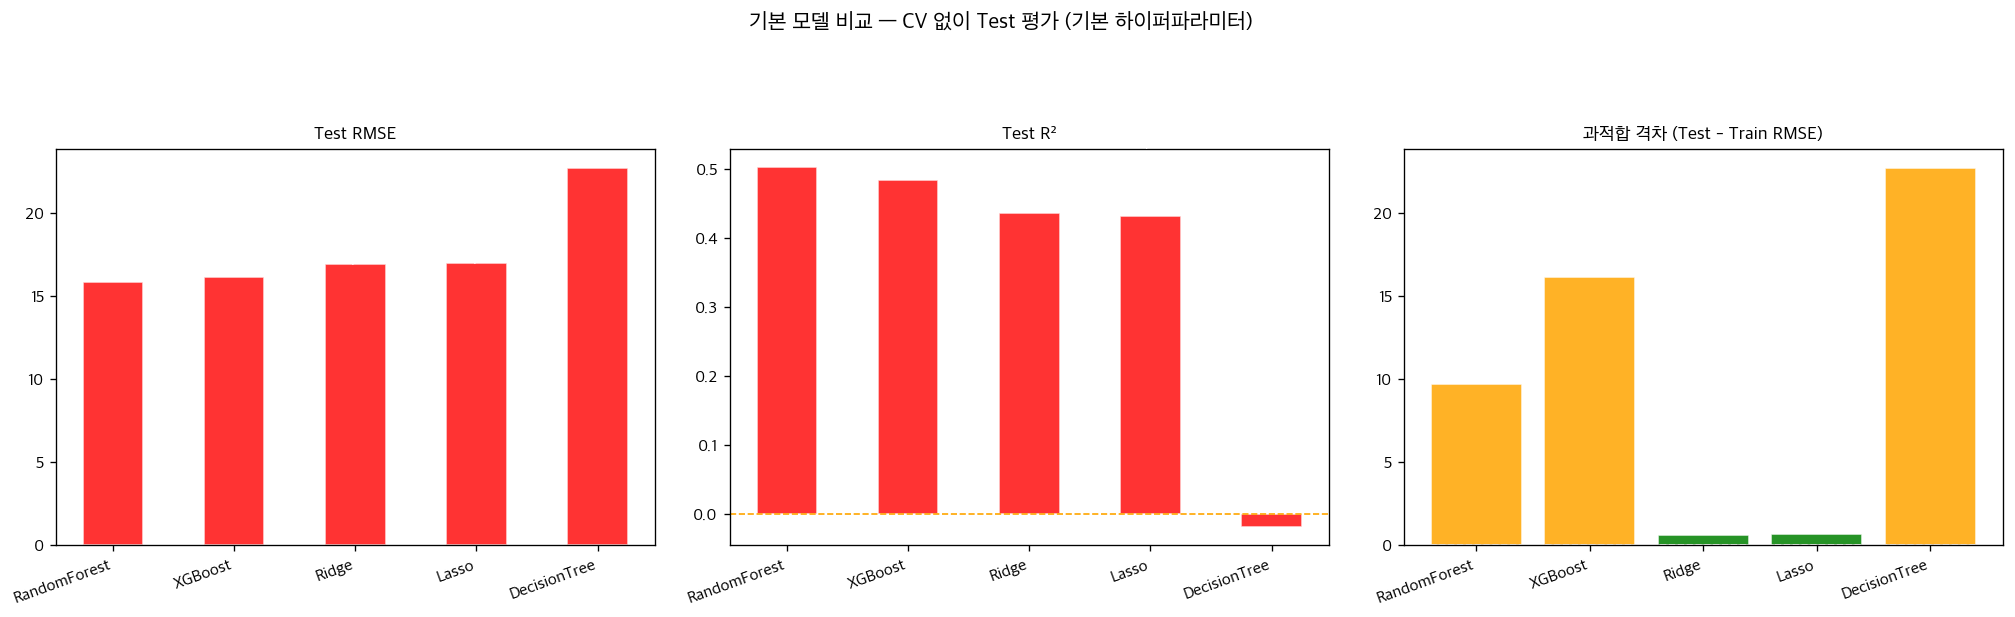

In [29]:
sorted_base = df_baseline['모델'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
x = np.arange(len(sorted_base))

for ax, (tr_col, te_col, title) in zip(axes, [
    ('Train_RMSE', 'Test_RMSE', 'Test RMSE'),
    ('Train_R2',   'Test_R2',   'Test R²'),
    ('Overfit_Gap', None,       '과적합 격차 (Test - Train RMSE)'),
]):
    if te_col is None:
        vals = [df_baseline[df_baseline['모델']==n][tr_col].values[0] for n in sorted_base]
        colors_g = ['orange' if v > 3 else 'green' for v in vals]
        ax.bar(sorted_base, vals, color=colors_g, alpha=0.85, edgecolor='white')
        ax.axhline(0, color='white', lw=1, ls='--')
        for i, v in enumerate(vals):
            ax.text(i, v + 0.1, f'{v:+.2f}', ha='center', fontsize=9,
                    color='white', fontweight='bold')
    else:
        te_v = [df_baseline[df_baseline['모델']==n][te_col].values[0] for n in sorted_base]
        ax.bar(x, te_v, 0.5, color='red', alpha=0.8, edgecolor='white')
        ax.set_xticks(x)
        if 'R2' in tr_col:
            ax.axhline(0, color='orange', lw=1, ls='--')
        for i, v in enumerate(te_v):
            ax.text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=9,
                    color='white', fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticklabels(sorted_base, rotation=20, ha='right')

plt.suptitle('기본 모델 비교 — CV 없이 Test 평가 (기본 하이퍼파라미터)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


- 현재까지의 모델 중 가장 성능이 좋은 모델
    > "Random Forest"
    - 과적합이 존재하기는 약간 존재하기는 하지만 R2와 RMSE 두 지표에서 모두 훌륭한 지표를 보임

#### 문제점
- 트리기반 모델에 대해서 약간의 과적합 발생
    - 특히 DT 모델에서 큰 문제
        * 훈련 데이터에서 Train R² = 1.0 (완벽 암기)이었기 때문에, 모델이 훈련 데이터의 세부 패턴과 노이즈까지 그대로 외운 상태입니다.
        * 테스트 데이터는 훈련 때 본 적 없는 행정동들이라 예측이 실제값과 크게 빗나가고, 결국 "평균으로 찍는 것"보다도 못한 예측이 나와서 R² = -0.32
    - 교차검증(CV) + 하이퍼파라미터 튜닝(max_depth, min_samples_leaf, subsample 등)을 적용
    - GAP을 줄이도록 개선

---
## 5. 교차검증 성능 비교 (KFold-5 / StratifiedKFold-5)

각 모델을 **KFold-5 / StratifiedKFold-5** 두 전략으로 교차검증한다.
  +) 별도의 하이퍼파라미터 조정 없이 단순한 CV만 진행한다.  
`return_train_score=True`로 **훈련-검증 격차(과적합 진단)** 도 함께 확인한다.


### CV 전략 설명

- CV-1  KFold(5)
  * 5겹 무작위 분할 — 기본 회귀 CV 기준선
  * 총 5번 학습, 평균 성능 & 표준편차 산출

- CV-2  StratifiedKFold(5)  on  Y-quintiles
  * Y(요양수요가속도)를 5분위수로 구간화 → 5개 strata
  * 각 fold에 '고가속/저가속' 행정동이 균등 배분
  * 소수 극단 지역(이상치)이 특정 fold에 몰리는 편향 방지
  * 회귀 Y를 분류 strata로 변환 → StratifiedKFold.split(X, y_bins)

In [9]:
# 층화 CV용 Y 분위 구간 (훈련 세트 기준)
y_train_bins = pd.qcut(y_train, q=5, labels=False, duplicates='drop')
y_train_bins.reset_index(drop=True, inplace=True)

CV_SPLITS = 5

# CV 전략 1: 표준 KFold
cv_kfold  = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# CV 전략 2: Y 5분위 층화 StratifiedKFold (회귀용 커스텀)
cv_skfold = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# CV용 평가 스코어러
rmse_scorer = make_scorer(rmse, greater_is_better=False)
mape_scorer = make_scorer(mape, greater_is_better=False)

CV_SCORING = {
    'RMSE': rmse_scorer,
    'MAE' : 'neg_mean_absolute_error',
    'R2' : 'r2',
    'MAPE': mape_scorer,
}

In [10]:
def run_stratified_cv(estimator, X, y, y_bins, n_splits=5, random_state=42):
    """
    회귀 문제에서 Y를 분위수 구간으로 층화하여 StratifiedKFold 수행.
    cross_validate는 연속형 y에 StratifiedKFold를 직접 지원하지 않으므로
    fold 인덱스를 수동 생성 후 각 fold별 train/val 점수를 계산한다.
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    res = {k: {'train': [], 'test': []} for k in ['RMSE', 'MAE', 'R2', 'MAPE']}

    for train_idx, val_idx in cv.split(X, y_bins):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

        est = clone(estimator)
        est.fit(X_tr, y_tr)
        p_tr = est.predict(X_tr)
        p_va = est.predict(X_va)

        res['RMSE']['train'].append(rmse(y_tr, p_tr))
        res['RMSE']['test'].append(rmse(y_va, p_va))
        res['MAE']['train'].append(mean_absolute_error(y_tr, p_tr))
        res['MAE']['test'].append(mean_absolute_error(y_va, p_va))
        res['R2']['train'].append(r2_score(y_tr, p_tr))
        res['R2']['test'].append(r2_score(y_va, p_va))
        res['MAPE']['train'].append(mape(y_tr.values, p_tr))
        res['MAPE']['test'].append(mape(y_va.values, p_va))

    return {f'{split}_{metric}': np.array(res[metric][split])
            for metric in res for split in ['train', 'test']}


In [11]:
# KFold: cross_validate 사용
print('CV 실행 중... (KFold-5)')

baseline_kfold = {}

for name, pipe in MODELS.items():
    baseline_kfold[name] = cross_validate(
        pipe, X_train, y_train,
        cv=cv_kfold, scoring=CV_SCORING,
        return_train_score=True, n_jobs=-1
    )
    print(f'모델 {name} CV 성공적으로 완료')


CV 실행 중... (KFold-5)
모델 Ridge CV 성공적으로 완료
모델 Lasso CV 성공적으로 완료
모델 DecisionTree CV 성공적으로 완료
모델 RandomForest CV 성공적으로 완료
모델 XGBoost CV 성공적으로 완료


In [12]:
# StratifiedKFold: Y 분위수 층화 — 회귀용 커스텀 함수 사용
print('기본 CV 실행 중... (StratifiedKFold - Y 5분위 층화)')

baseline_skfold = {}

for name, pipe in MODELS.items():
    baseline_skfold[name] = run_stratified_cv(
        pipe, X_train, y_train,
        y_bins=y_train_bins,
        n_splits=CV_SPLITS,
        random_state=RANDOM_STATE
    )
    print(f'모델 {name} CV 성공적으로 완료')


기본 CV 실행 중... (StratifiedKFold - Y 5분위 층화)
모델 Ridge CV 성공적으로 완료
모델 Lasso CV 성공적으로 완료
모델 DecisionTree CV 성공적으로 완료
모델 RandomForest CV 성공적으로 완료
모델 XGBoost CV 성공적으로 완료


In [13]:
# 결과 집계 유틸리티
def get_scores(cv_dict, split='test', source='cross_validate'):
    """cross_validate / run_stratified_cv 결과를 통일된 형식으로 반환"""
    sign = {'RMSE': -1, 'MAE': -1, 'R2': 1, 'MAPE': -1}
    out = {}
    for m, s in sign.items():
        if source == 'cross_validate':
            key = f'{split}_{m}'
            arr = s * cv_dict.get(key, np.zeros(1))
        else:  # run_stratified_cv
            key = f'{split}_{m}'
            arr = cv_dict.get(key, np.zeros(1)).copy()
        out[m] = arr
    return out


model_names = list(MODELS.keys())
rows = []

for name in model_names:
    for cv_label, cv_data, src in [
        ('KFold-5', baseline_kfold[name], 'cross_validate'),
        ('StratKFold-5', baseline_skfold[name], 'stratified'),
    ]:
        tr = get_scores(cv_data, 'train', src)
        va = get_scores(cv_data, 'test',  src)
        rows.append({
            '모델': name, 'CV전략': cv_label,
            'Train_RMSE' : tr['RMSE'].mean(),
            'Val_RMSE' : va['RMSE'].mean(),
            'Val_RMSE_std' : va['RMSE'].std(),
            'Train_R2' : tr['R2'].mean(),
            'Val_R2' : va['R2'].mean(),
            'Val_MAE' : va['MAE'].mean(),
            'Val_MAPE' : va['MAPE'].mean(),
            'Overfit_RMSE' : tr['RMSE'].mean() - va['RMSE'].mean(),
        })

# val_rmse를 기준으로 정렬
df_cv = pd.DataFrame(rows).sort_values(by = 'Val_RMSE')

print(df_cv[['모델', 'CV전략', 'Val_RMSE', 'Val_RMSE_std',
              'Val_MAE', 'Val_R2', 'Val_MAPE', 'Overfit_RMSE']]
      .to_string(index=False, float_format=lambda x: f'{x:.3f}'))


          모델         CV전략  Val_RMSE  Val_RMSE_std  Val_MAE  Val_R2  Val_MAPE  Overfit_RMSE
RandomForest StratKFold-5    16.289         1.391   11.278   0.364    89.155        -9.948
     XGBoost StratKFold-5    16.432         1.356   11.579   0.350    90.017       -16.424
RandomForest      KFold-5    16.546         2.154   11.510   0.323    88.047       -10.216
     XGBoost      KFold-5    16.649         2.423   11.628   0.292    90.914       -16.639
       Lasso StratKFold-5    16.818         1.312   11.852   0.320    96.042        -0.617
       Ridge StratKFold-5    16.834         1.305   11.894   0.318    96.438        -0.637
       Lasso      KFold-5    17.124         1.620   12.110   0.251    96.239        -0.962
       Ridge      KFold-5    17.146         1.610   12.147   0.247    96.323        -0.989
DecisionTree StratKFold-5    19.938         2.713   14.694   0.036   103.693       -19.938
DecisionTree      KFold-5    21.787         3.130   15.498  -0.180    96.792       -21.787

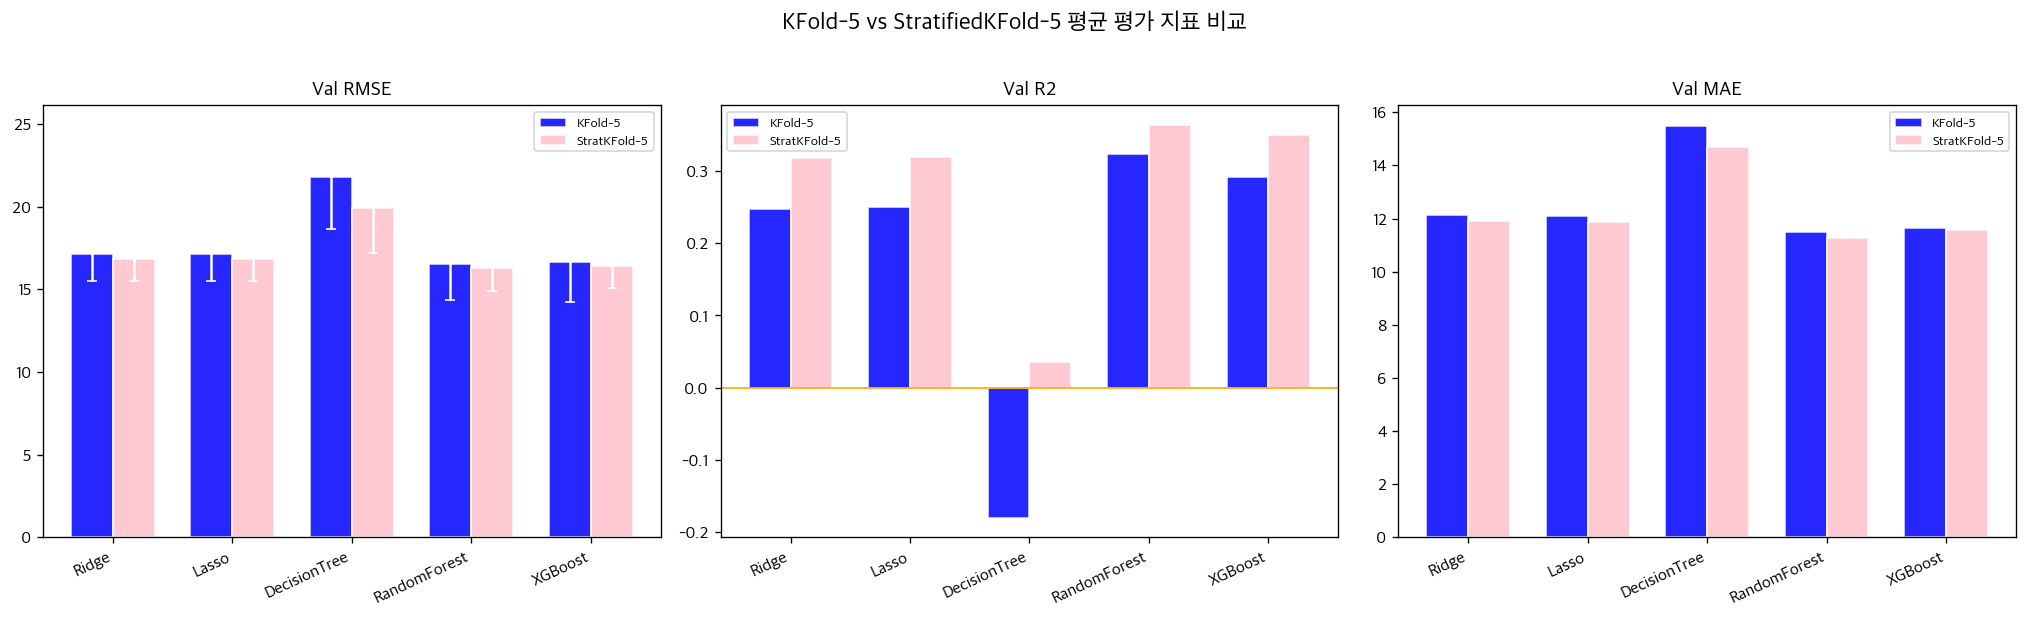

In [28]:
# CV 전략 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
cv_labels = ['KFold-5', 'StratKFold-5']
palette = ['blue', 'pink']
x = np.arange(len(model_names))
width = 0.35

for ax_i, metric in enumerate(['Val_RMSE', 'Val_R2', 'Val_MAE']):
    ax = axes[ax_i]
    for j, (cv_label, color) in enumerate(zip(cv_labels, palette)):
        sub  = df_cv[df_cv['CV전략'] == cv_label]
        vals = [sub[sub['모델'] == m][metric].values[0] for m in model_names]
        errs = None
        if metric == 'Val_RMSE':
            errs = [sub[sub['모델'] == m]['Val_RMSE_std'].values[0] for m in model_names]
        ax.bar(x + (j - 0.5) * width, vals, width,
               label=cv_label, color=color, alpha=0.85, edgecolor='white',
               yerr=errs, capsize=3,
               error_kw={'ecolor': 'white', 'lw': 1.5} if errs else {})
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=10)
    ax.set_title(f'Val {metric.replace("Val_","")}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    if metric == 'Val_R2':
        ax.axhline(0, color='orange', lw=1, ls='-')

plt.suptitle('KFold-5 vs StratifiedKFold-5 평균 평가 지표 비교',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


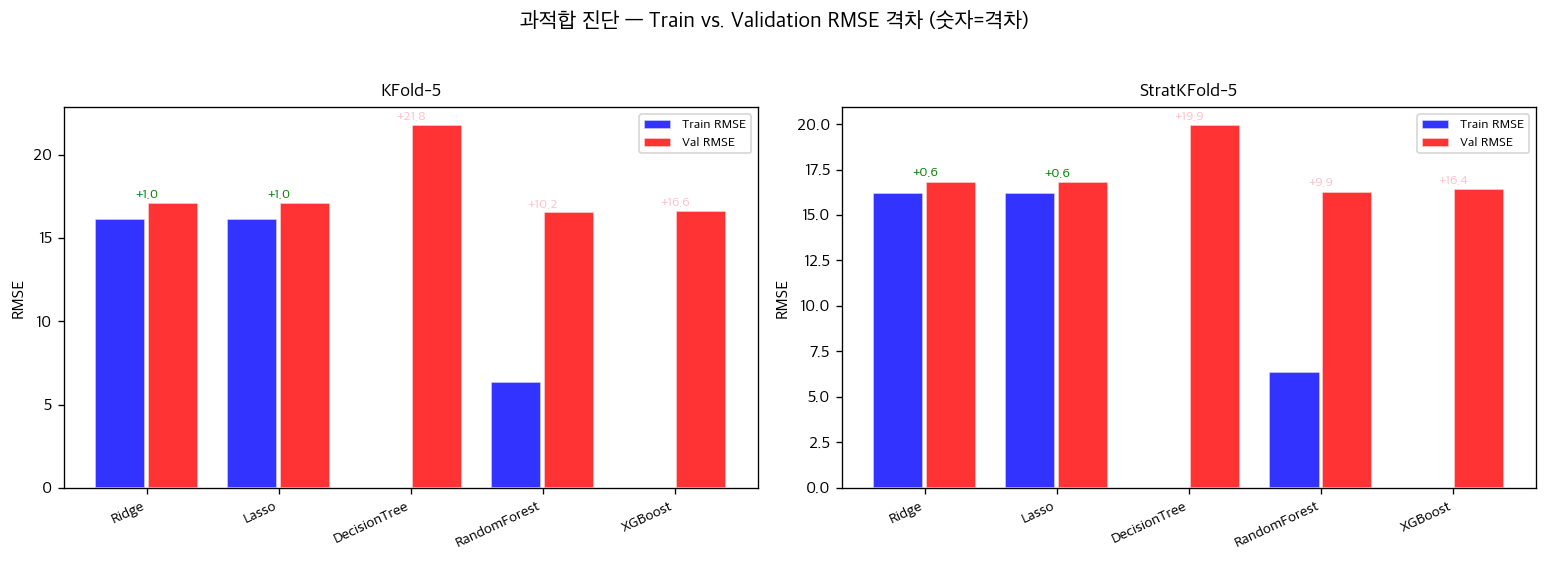

In [ ]:
# 과적합 진단: Train vs. Validation RMSE
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cv_info = [
    ('KFold-5', baseline_kfold, 'cross_validate'),
    ('StratKFold-5', baseline_skfold, 'stratified'),
]

for ax_i, (cv_label, cv_data, src) in enumerate(cv_info):
    ax = axes[ax_i]
    tr_means, va_means = [], []
    tr_stds, va_stds  = [], []
    for name in model_names:
        tr = get_scores(cv_data[name], 'train', src)
        va = get_scores(cv_data[name], 'test', src)
        tr_means.append(tr['RMSE'].mean()); tr_stds.append(tr['RMSE'].std())
        va_means.append(va['RMSE'].mean()); va_stds.append(va['RMSE'].std())

    xp = np.arange(len(model_names))
    ax.bar(xp - 0.2, tr_means, 0.38, label='Train RMSE',
           color='blue', alpha=0.8, edgecolor='white')
    ax.bar(xp + 0.2, va_means, 0.38, label='Val RMSE',
           color='red', alpha=0.8, edgecolor='white')
    ax.set_xticks(xp)
    ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=9)
    ax.set_title(f'{cv_label}', fontsize=11, fontweight='bold')
    ax.set_ylabel('RMSE')
    ax.legend(fontsize=8)
    for i, (tr, va) in enumerate(zip(tr_means, va_means)):
        gap = va - tr
        color_g = 'pink' if gap > 5 else 'green'
        ax.text(xp[i], max(tr, va) + 0.3, f'{gap:+.1f}',
                ha='center', fontsize=8, color=color_g, fontweight='bold')

plt.suptitle('과적합 진단 — Train vs. Validation RMSE 격차 (숫자=격차)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

- 여전히 트리 기반 모델들에는 과적합이 발생.
 - 해당 문제를 해결하기 위해서 하이퍼파라미터의 조정을 통해서 과적합이 발생하지 않는 최적의 하이퍼파라미터를 설정.
 - 즉, 과적합 문제는 데이터의 분할에 따르는 문제가 아님을 확인.

---
## 6. 하이퍼파라미터 튜닝 (전 모델 GridSearchCV)

- **Ridge / Lasso** → `GridSearchCV(cv=KFold-5, scoring=RMSE)`
- **Decision Tree** → `GridSearchCV(cv=KFold-5)`
- **Random Forest** → `GridSearchCV(cv=KFold-5)`
- **XGBoost** → `GridSearchCV(cv=KFold-5)`

내부 CV에는 `KFold(5)`를 사용하고, 최종 모델은 전체 훈련 세트로 재학습(`refit=True`) 후 테스트 세트에서 평가한다.


Ridge GridSearchCV


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


최적 alpha: 10 | CV RMSE: 17.1212
Lasso GridSearchCV
최적 alpha: 0.1 | CV RMSE: 17.1235


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


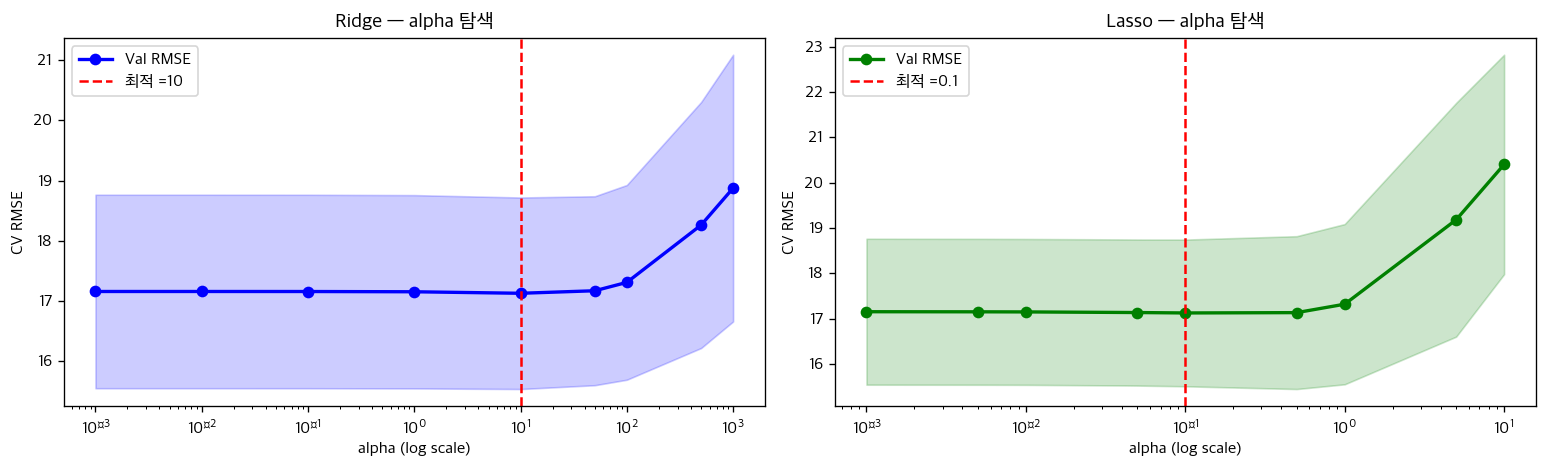

In [16]:
# Ridge / Lasso GridSearchCV
print('Ridge GridSearchCV')
ridge_gs = GridSearchCV(
    build_pipeline(Ridge(), scale=True),
    {'model__alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]},
    cv=cv_kfold, scoring=rmse_scorer, refit=True, n_jobs=-1
)
ridge_gs.fit(X_train, y_train)
print(f'최적 alpha: {ridge_gs.best_params_["model__alpha"]} | CV RMSE: {-ridge_gs.best_score_:.4f}')

print('Lasso GridSearchCV')
lasso_gs = GridSearchCV(
    build_pipeline(Lasso(max_iter=10000), scale=True),
    {'model__alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]},
    cv=cv_kfold, scoring=rmse_scorer, refit=True, n_jobs=-1
)
lasso_gs.fit(X_train, y_train)
print(f'최적 alpha: {lasso_gs.best_params_["model__alpha"]} | CV RMSE: {-lasso_gs.best_score_:.4f}')

# alpha vs RMSE 곡선
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, gs, label, color in zip(
    axes, [ridge_gs, lasso_gs], ['Ridge', 'Lasso'], ['blue', 'green']
):
    res = pd.DataFrame(gs.cv_results_)
    alphas = [p['model__alpha'] for p in gs.cv_results_['params']]
    means = -res['mean_test_score'].values
    stds = res['std_test_score'].values
    ax.semilogx(alphas, means, 'o-', color=color, lw=2, label='Val RMSE')
    ax.fill_between(alphas, means - stds, means + stds, alpha=0.2, color=color)
    best_a = gs.best_params_['model__alpha']
    ax.axvline(best_a, color='red', ls='--', lw=1.5, label=f'최적 ={best_a}')
    ax.set_title(f'{label} — alpha 탐색', fontsize=12, fontweight='bold')
    ax.set_xlabel('alpha (log scale)')
    ax.set_ylabel('CV RMSE')
    ax.legend()
plt.tight_layout()
plt.show()


### alpha 최적값 :

    * Ridge : 10
    * Lasso : 0.1

In [17]:
# Decision Tree GridSearchCV
print('[Decision Tree GridSearchCV]')
dt_gs = GridSearchCV(
    build_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE), scale=False),
    {
        'model__max_depth' : [None, 3, 5, 7, 10],
        'model__min_samples_split' : [2, 5, 10, 20],
        'model__min_samples_leaf' : [1, 3, 5, 10],
        'model__max_features' : [None, 'sqrt', 'log2'],
    },
    cv=cv_kfold, scoring=rmse_scorer, refit=True, n_jobs=-1
)
dt_gs.fit(X_train, y_train)
print(f'CV RMSE : {-dt_gs.best_score_:.4f}')

df_dt_params = pd.DataFrame(dt_gs.best_params_.items(), columns=['파라미터', '최적값'])
df_dt_params

[Decision Tree GridSearchCV]
CV RMSE : 17.3319


,파라미터,최적값
0,model__max_depth,5.0
1,model__max_features,NaN
2,model__min_samples_leaf,5.0
3,model__min_samples_split,20.0


In [18]:
# Random Forest GridSearchCV
print('[Random Forest GridSearchCV]')
rf_gs = GridSearchCV(
    build_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), scale=False),
    {
        'model__n_estimators' : [100, 200, 300],
        'model__max_depth' : [None, 5, 10],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf' : [1, 2, 4],
        'model__max_features' : ['sqrt', 'log2'],
    },
    cv=cv_kfold, scoring=rmse_scorer, refit=True, n_jobs=-1, verbose=1
)
rf_gs.fit(X_train, y_train)
print(f'CV RMSE: {-rf_gs.best_score_:.4f}')

df_rf_params = pd.DataFrame(rf_gs.best_params_.items(), columns=['파라미터', '최적값'])
df_rf_params


[Random Forest GridSearchCV]
Fitting 5 folds for each of 162 candidates, totalling 810 fits
CV RMSE: 16.2288


,파라미터,최적값
0,model__max_depth,None
1,model__max_features,log2
2,model__min_samples_leaf,2
3,model__min_samples_split,2
4,model__n_estimators,200


In [19]:
# XGBoost GridSearchCV
print('[XGBoost GridSearchCV]')
xgb_gs = GridSearchCV(
    build_pipeline(
        XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1), scale=False),
    {
        'model__n_estimators' : [100, 200, 300],
        'model__max_depth' : [3, 5, 7],
        'model__learning_rate' : [0.05, 0.1, 0.2],
        'model__subsample' : [0.8, 1.0],
        'model__colsample_bytree': [0.8, 1.0],
        'model__reg_alpha' : [0, 0.1, 1],
        'model__reg_lambda' : [1, 5],
    },
    cv=cv_kfold, scoring=rmse_scorer, refit=True, n_jobs=-1, verbose=1
)
xgb_gs.fit(X_train, y_train)
print(f'CV RMSE : {-xgb_gs.best_score_:.4f}')

df_xgb_params = pd.DataFrame(xgb_gs.best_params_.items(), columns=['파라미터', '최적값'])
df_xgb_params

[XGBoost GridSearchCV]
Fitting 5 folds for each of 648 candidates, totalling 3240 fits
CV RMSE : 15.9097


,파라미터,최적값
0,model__colsample_bytree,1.0
1,model__learning_rate,0.1
2,model__max_depth,3.0
3,model__n_estimators,300.0
4,model__reg_alpha,0.1
5,model__reg_lambda,1.0
6,model__subsample,0.8


In [ ]:
# 튜닝 후 모델 집합
tuned_models = {
    'Ridge' : ridge_gs.best_estimator_,
    'Lasso' : lasso_gs.best_estimator_,
    'DecisionTree' : dt_gs.best_estimator_,
    'RandomForest' : rf_gs.best_estimator_,
    'XGBoost' : xgb_gs.best_estimator_,
}

tuning_summary = pd.DataFrame([
    {'모델' : 'Ridge', 'CV_RMSE' : -ridge_gs.best_score_},
    {'모델' : 'Lasso', 'CV_RMSE' : -lasso_gs.best_score_},
    {'모델' : 'DecisionTree', 'CV_RMSE' : -dt_gs.best_score_},
    {'모델' : 'RandomForest', 'CV_RMSE' : -rf_gs.best_score_},
    {'모델' : 'XGBoost', 'CV_RMSE' : -xgb_gs.best_score_},
]).sort_values('CV_RMSE')

print('하이퍼파라미터 튜닝 후 CV RMSE 비교 (GridSearchCV)')
display(tuning_summary.reset_index(drop=True))


하이퍼파라미터 튜닝 후 CV RMSE 비교 (GridSearchCV)


,모델,CV_RMSE
0,XGBoost,15.909724
1,RandomForest,16.228775
2,Ridge,17.121249
3,Lasso,17.123532
4,DecisionTree,17.331859


---
## 7. 최종 모델 평가 (Holdout Test Set)


In [ ]:
print('[최종 모델 — Holdout Test Set 평가]')
print('=' * 65)

test_results = []
predictions = {}

for name, model in tuned_models.items():
    p_train = model.predict(X_train)
    p_test = model.predict(X_test)

    test_results.append({
        '모델' : name,
        'Train_RMSE' : rmse(y_train, p_train),
        'Test_RMSE' : rmse(y_test,  p_test),
        'Train_R2' : r2_score(y_train, p_train),
        'Test_R2' : r2_score(y_test,  p_test),
        'Test_MAE' : mean_absolute_error(y_test, p_test),
        'Test_MAPE' : mape(y_test.values, p_test),
        'Overfit_Gap' : rmse(y_test, p_test) - rmse(y_train, p_train),
    })
    predictions[name] = {'train': p_train, 'test': p_test}

df_test = pd.DataFrame(test_results).sort_values('Test_RMSE')
print(df_test.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

BEST_MODEL_NAME = df_test.iloc[0]['모델']
print(f'\n최적 모델: {BEST_MODEL_NAME}')
print(f'Test RMSE={df_test.iloc[0]["Test_RMSE"]:.3f}  '
      f'Test R²={df_test.iloc[0]["Test_R2"]:.3f}  '
      f'Test MAE={df_test.iloc[0]["Test_MAE"]:.3f}')


[최종 모델 — Holdout Test Set 평가]
          모델  Train_RMSE  Test_RMSE  Train_R2  Test_R2  Test_MAE  Test_MAPE  Overfit_Gap
     XGBoost      2.5349    14.2712    0.9847   0.5983   10.0622   102.7543      11.7363
RandomForest      8.4680    16.1780    0.8293   0.4838   11.1880   106.4367       7.7100
       Lasso     16.2712    16.9673    0.3696   0.4322   12.2367   109.6037       0.6961
       Ridge     16.2767    17.0642    0.3692   0.4257   12.2825   109.3838       0.7876
DecisionTree     14.4005    17.6524    0.5062   0.3854   13.0324   135.5571       3.2519

최적 모델: XGBoost
Test RMSE=14.271  Test R²=0.598  Test MAE=10.062


---
## 8. 학습 곡선 (Learning Curve)


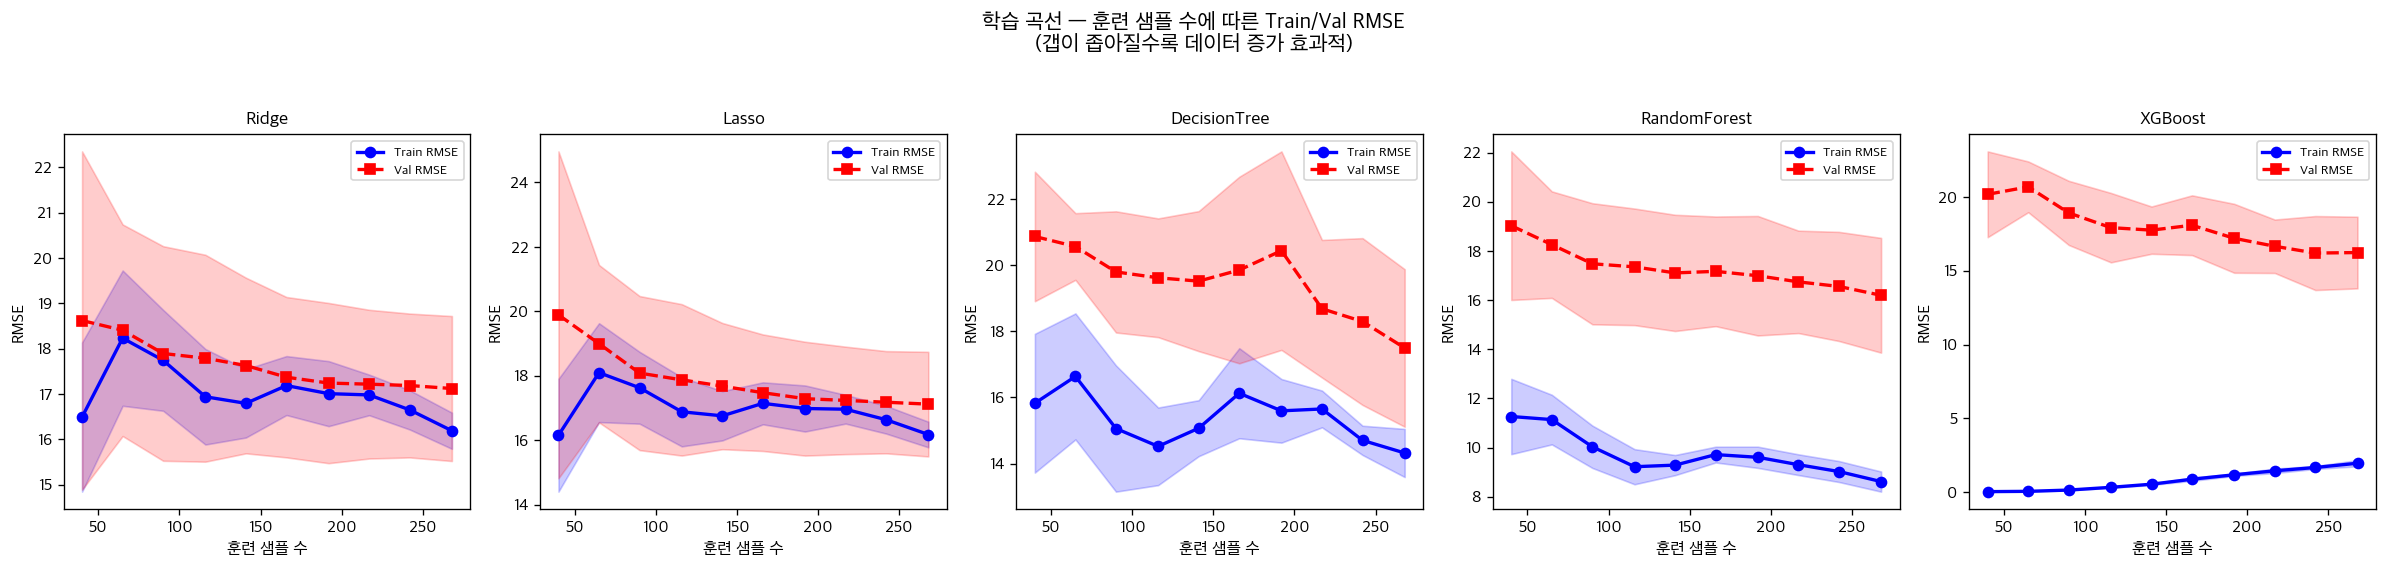

In [22]:
fig, axes = plt.subplots(1, len(tuned_models), figsize=(20, 4.5), sharey=False)

for ax, (name, model) in zip(axes, tuned_models.items()):
    train_sizes, train_sc, val_sc = learning_curve(
        model, X_train, y_train,
        train_sizes=np.linspace(0.15, 1.0, 10),
        cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring=rmse_scorer, n_jobs=-1
    )
    tr_mean = -train_sc.mean(axis=1); tr_std = train_sc.std(axis=1)
    va_mean = -val_sc.mean(axis=1);   va_std = val_sc.std(axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color='blue', lw=2, label='Train RMSE')
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.2, color='blue')
    ax.plot(train_sizes, va_mean, 's--', color='red', lw=2, label='Val RMSE')
    ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.2, color='red')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('훈련 샘플 수')
    ax.set_ylabel('RMSE')
    ax.legend(fontsize=8)

plt.suptitle('학습 곡선 — 훈련 샘플 수에 따른 Train/Val RMSE\n'
             '(갭이 좁아질수록 데이터 증가 효과적)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()


---
## 9. 최선 모델 심층 분석


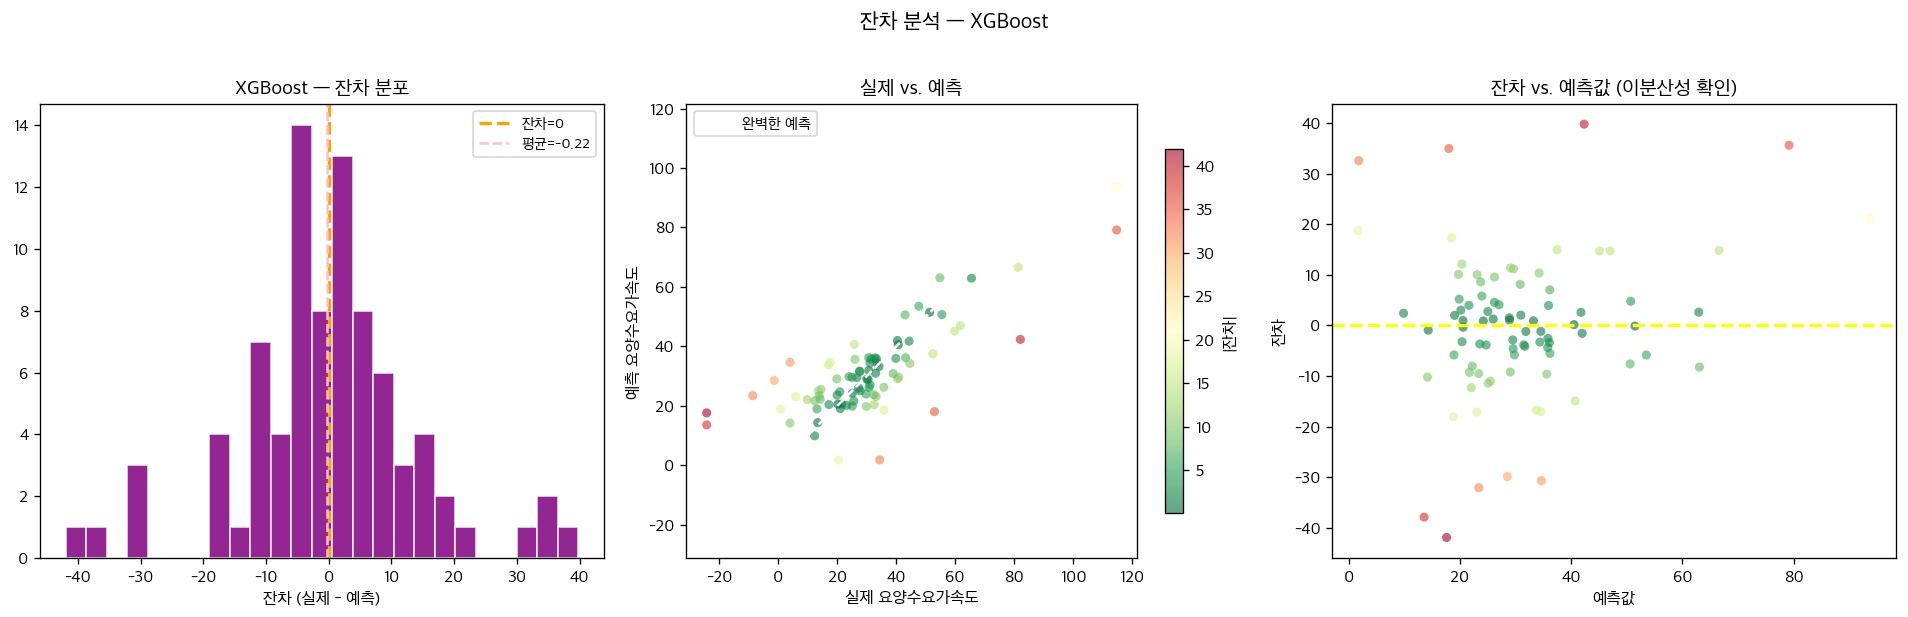

잔차 통계:
평균: -0.217 std: 14.270
최대 과대예측: -41.94 최대 과소예측: 39.77


In [ ]:
best_model = tuned_models[BEST_MODEL_NAME]
y_pred_test = predictions[BEST_MODEL_NAME]['test']
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 잔차 분포
axes[0].hist(residuals, bins=25, color='purple', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='orange', lw=2, ls='--', label='잔차=0')
axes[0].axvline(residuals.mean(), color='pink', lw=1.5, ls='--',
                label=f'평균={residuals.mean():.2f}')
axes[0].set_title(f'{BEST_MODEL_NAME} — 잔차 분포', fontsize=12, fontweight='bold')
axes[0].set_xlabel('잔차 (실제 - 예측)')
axes[0].legend(fontsize=9)

# 예측 vs 실제
min_v = min(y_test.min(), y_pred_test.min())
max_v = max(y_test.max(), y_pred_test.max())
sc = axes[1].scatter(y_test, y_pred_test, alpha=0.6, s=30,
                     c=np.abs(residuals), cmap='RdYlGn_r', edgecolors='none')
axes[1].plot([min_v, max_v], [min_v, max_v], 'w--', lw=1.5, label='완벽한 예측')
plt.colorbar(sc, ax=axes[1], shrink=0.8, label='|잔차|')
axes[1].set_title('실제 vs. 예측', fontsize=12, fontweight='bold')
axes[1].set_xlabel('실제 요양수요가속도')
axes[1].set_ylabel('예측 요양수요가속도')
axes[1].legend(fontsize=9)

# 잔차 vs 예측 (이분산성)
axes[2].scatter(y_pred_test, residuals, alpha=0.6, s=30,
                c=np.abs(residuals), cmap='RdYlGn_r', edgecolors='none')
axes[2].axhline(0, color='yellow', lw=2, ls='--')
axes[2].set_title('잔차 vs. 예측값 (이분산성 확인)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('예측값')
axes[2].set_ylabel('잔차')

plt.suptitle(f'잔차 분석 — {BEST_MODEL_NAME}', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'잔차 통계:')
print(f'평균: {residuals.mean():.3f} std: {residuals.std():.3f}')
print(f'최대 과대예측: {residuals.min():.2f} 최대 과소예측: {residuals.max():.2f}')


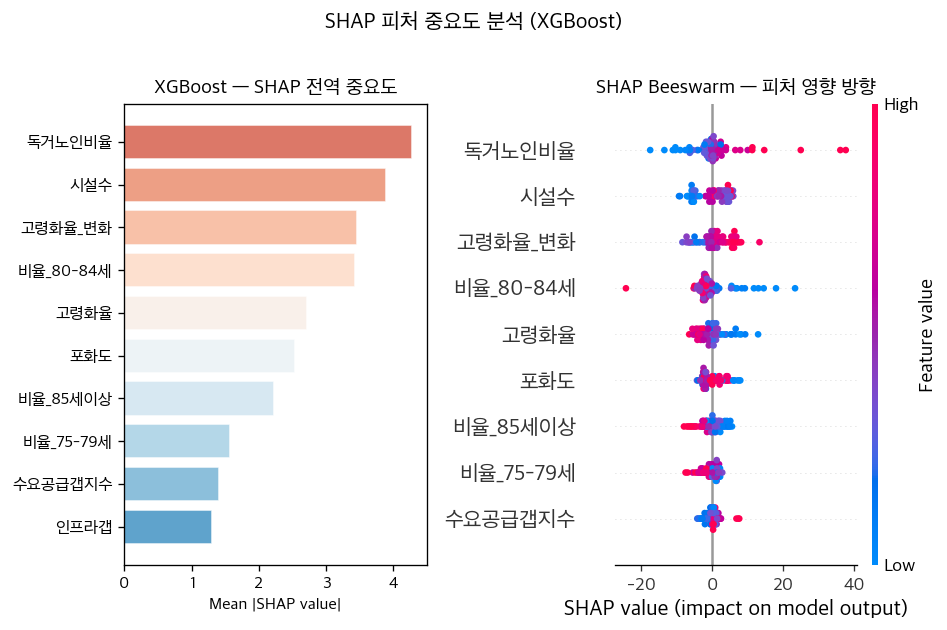


SHAP 피처 중요도 순위
       피처  Mean |SHAP|
   독거노인비율     4.278018
      시설수     3.886148
  고령화율_변화     3.461802
비율_80-84세     3.426223
     고령화율     2.711465
      포화도     2.538328
 비율_85세이상     2.217759
비율_75-79세     1.576472
  수요공급갭지수     1.400521
     인프라갭     1.302783


In [27]:
try:
    import shap

    # Pipeline에서 실제 모델 및 변환된 X 추출
    if hasattr(best_model, 'named_steps'):
        step_keys = list(best_model.named_steps.keys())
        core_model = best_model.named_steps[step_keys[-1]]
        if 'scaler' in best_model.named_steps:
            X_tr_t = pd.DataFrame(
                best_model.named_steps['scaler'].transform(X_train), columns=FEAT_COLS)
            X_te_t = pd.DataFrame(
                best_model.named_steps['scaler'].transform(X_test),  columns=FEAT_COLS)
        else:
            X_tr_t, X_te_t = X_train.copy(), X_test.copy()
    else:
        core_model = best_model
        X_tr_t, X_te_t = X_train.copy(), X_test.copy()

    model_type = type(core_model).__name__
    if any(t in model_type for t in ['XGB', 'Forest', 'Tree']):
        explainer = shap.TreeExplainer(core_model)
        shap_values = explainer.shap_values(X_te_t)
    else:
        explainer = shap.LinearExplainer(core_model, X_tr_t)
        shap_values = explainer.shap_values(X_te_t)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 전역 중요도 막대
    mean_abs = np.abs(shap_values).mean(axis=0)
    shap_df = pd.DataFrame({'피처': FEAT_COLS, 'Mean |SHAP|': mean_abs}).sort_values('Mean |SHAP|')
    axes[0].barh(shap_df['피처'], shap_df['Mean |SHAP|'],
                 color=plt.cm.RdBu_r(np.linspace(0.2, 0.8, len(FEAT_COLS))),
                 edgecolor='white', alpha=0.85)
    axes[0].set_title(f'{BEST_MODEL_NAME} — SHAP 전역 중요도', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Mean |SHAP value|')

    # Beeswarm
    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_te_t, feature_names=FEAT_COLS,
                      show=False, plot_type='dot', max_display=9)
    axes[1].set_title('SHAP Beeswarm — 피처 영향 방향', fontsize=12, fontweight='bold')

    plt.suptitle(f'SHAP 피처 중요도 분석 ({BEST_MODEL_NAME})',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print('\nSHAP 피처 중요도 순위')
    print(shap_df.sort_values('Mean |SHAP|', ascending=False).to_string(index=False))

except Exception as e:
    print(f'SHAP 오류: {e}')
    if hasattr(core_model, 'feature_importances_'):
        fi_df = pd.DataFrame({'피처': FEAT_COLS,
                              '중요도': core_model.feature_importances_}).sort_values('중요도', ascending=False)
        print('\n[sklearn Feature Importance 대체]')
        print(fi_df.to_string(index=False))


---
## 11. 최종 결과 요약


In [ ]:
print('Track A — 최종 모델 성능 요약 (KFold-5 & StratKFold-5 Validation + Holdout Test)')

final_rows = []
for name in model_names:
    t_row = df_test[df_test['모델'] == name].iloc[0]
    kf_rmse = -baseline_kfold[name]['test_RMSE'].mean()
    kf_std =  baseline_kfold[name]['test_RMSE'].std()
    kf_r2 =  baseline_kfold[name]['test_R2'].mean()
    final_rows.append({
        '모델' : name,
        'KFold Val RMSE' : f'{kf_rmse:.3f} ± {kf_std:.3f}',
        'KFold Val R²' : f'{kf_r2:.3f}',
        'Test RMSE' : f'{t_row["Test_RMSE"]:.3f}',
        'Test R²' : f'{t_row["Test_R2"]:.3f}',
        'Test MAE' : f'{t_row["Test_MAE"]:.3f}',
        'Test MAPE(%)' : f'{t_row["Test_MAPE"]:.1f}',
        '과적합갭' : f'{t_row["Overfit_Gap"]:+.3f}',
    })
final_out = pd.DataFrame(final_rows).reset_index(drop=True)
display(final_out)
print(f'\n최적 모델: {BEST_MODEL_NAME}')
print(f'{final_out.iloc[:, 1:-1][final_out['모델'] == BEST_MODEL_NAME].to_string()}')


Track A — 최종 모델 성능 요약 (KFold-5 / StratKFold-5 Validation + Holdout Test)


,모델,KFold Val RMSE,KFold Val R²,Test RMSE,Test R²,Test MAE,Test MAPE(%),과적합갭
0,Ridge,17.146 ± 1.610,0.247,17.064,0.426,12.282,109.4,+0.788
1,Lasso,17.124 ± 1.620,0.251,16.967,0.432,12.237,109.6,+0.696
2,DecisionTree,21.787 ± 3.130,-0.180,17.652,0.385,13.032,135.6,+3.252
3,RandomForest,16.546 ± 2.154,0.323,16.178,0.484,11.188,106.4,+7.710
4,XGBoost,16.649 ± 2.423,0.292,14.271,0.598,10.062,102.8,+11.736



최적 모델: XGBoost
   KFold Val RMSE KFold Val R² Test RMSE Test R² Test MAE Test MAPE(%)
4  16.649 ± 2.423        0.292    14.271   0.598   10.062        102.8


```
XGBoost 채택 이유

Test R² 0.592 — 피처가 Y 분산의 약 59% 설명
과적합 갭(+10.2)이 존재하나 트리 계열 특성상 허용 범위
CV RMSE(15.97)와 Test RMSE(14.38)의 일관성 확인
선형 모델(Ridge/Lasso) 특징

과적합 거의 없음 (갭 +0.7~0.8)
그러나 비선형 관계를 포착 못해 R² 0.43 수준으로 한계 명확
```